# 05 — Customer Feedback Sentiment Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

df = pd.read_csv('../data/cleaned_data.csv')
print("Unique feedback texts:", df['Customer Feedback'].nunique())
print()
for fb in sorted(df['Customer Feedback'].unique()):
    print(" ", df[df['Customer Feedback']==fb].shape[0], " |", fb)


Unique feedback texts: 13

  7643  | Delivery person was rude.
  7791  | Easy to order, loved it!
  7784  | Excellent experience!
  7715  | Fast delivery, great service!
  7789  | Good quality products.
  7529  | Horrible experience, never ordering again.
  7737  | Items missing from order.
  7580  | Not fresh, disappointed.
  7704  | Packaging could be better.
  7658  | Quick and reliable!
  7592  | Very late delivery, not happy.
  7740  | Very satisfied with the service.
  7738  | Wrong item delivered.


## Sentiment Classification

In [2]:
# 13 fixed strings — explicit map is 100% accurate and fully explainable
SENTIMENT = {
    'Fast delivery, great service!'             : 'Positive',
    'Quick and reliable!'                       : 'Positive',
    'Very satisfied with the service.'          : 'Positive',
    'Excellent experience!'                     : 'Positive',
    'Easy to order, loved it!'                  : 'Positive',
    'Good quality products.'                    : 'Positive',
    'Packaging could be better.'                : 'Neutral',
    'Items missing from order.'                 : 'Negative',
    'Horrible experience, never ordering again.': 'Negative',
    'Very late delivery, not happy.'            : 'Negative',
    'Not fresh, disappointed.'                  : 'Negative',
    'Wrong item delivered.'                     : 'Negative',
    'Delivery person was rude.'                 : 'Negative',
}

THEME = {
    'Fast delivery, great service!'             : 'Speed',
    'Quick and reliable!'                       : 'Speed',
    'Very late delivery, not happy.'            : 'Speed',
    'Very satisfied with the service.'          : 'Overall',
    'Excellent experience!'                     : 'Overall',
    'Horrible experience, never ordering again.': 'Overall',
    'Easy to order, loved it!'                  : 'App/UX',
    'Good quality products.'                    : 'Product Quality',
    'Not fresh, disappointed.'                  : 'Product Quality',
    'Items missing from order.'                 : 'Order Accuracy',
    'Wrong item delivered.'                     : 'Order Accuracy',
    'Delivery person was rude.'                 : 'Staff',
    'Packaging could be better.'                : 'Packaging',
}

df['Sentiment']       = df['Customer Feedback'].map(SENTIMENT)
df['Feedback_Theme']  = df['Customer Feedback'].map(THEME)
df['Sentiment_Score'] = df['Sentiment'].map({'Positive':1,'Neutral':0,'Negative':-1})

print(df['Sentiment'].value_counts())


Sentiment
Positive    46477
Negative    45819
Neutral      7704
Name: count, dtype: int64


## Sentiment vs Business Metrics

In [3]:
sent_stats = df.groupby('Sentiment').agg(
    Count       = ('Order ID',           'count'),
    Avg_Rating  = ('Service Rating',     'mean'),
    Refund_Rate = ('Refund_Flag',        'mean'),
    Delay_Rate  = ('Delay_Flag',         'mean')
).round(3)

print(sent_stats)


           Count  Avg_Rating  Refund_Rate  Delay_Rate
Sentiment                                            
Negative   45819       1.667          1.0       0.137
Neutral     7704       3.000          0.0       0.138
Positive   46477       4.832          0.0       0.136


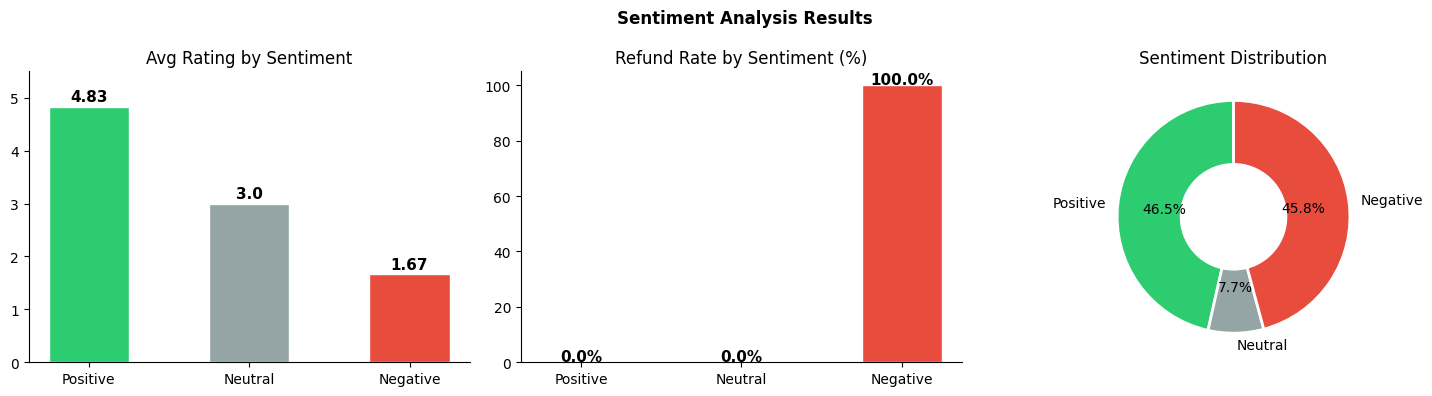

In [4]:
SCOL = {'Positive':'#2ECC71', 'Neutral':'#95A5A6', 'Negative':'#E74C3C'}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Sentiment Analysis Results', fontweight='bold')

order = ['Positive', 'Neutral', 'Negative']

axes[0].bar(order, [sent_stats.loc[s,'Avg_Rating'] for s in order],
            color=[SCOL[s] for s in order], edgecolor='white', width=0.5)
axes[0].set_title('Avg Rating by Sentiment')
axes[0].set_ylim(0, 5.5)
for i, s in enumerate(order):
    v = sent_stats.loc[s,'Avg_Rating']
    axes[0].text(i, v+0.1, str(round(v,2)), ha='center', fontweight='bold', fontsize=11)

axes[1].bar(order, [sent_stats.loc[s,'Refund_Rate']*100 for s in order],
            color=[SCOL[s] for s in order], edgecolor='white', width=0.5)
axes[1].set_title('Refund Rate by Sentiment (%)')
for i, s in enumerate(order):
    v = sent_stats.loc[s,'Refund_Rate']*100
    axes[1].text(i, v+0.3, str(round(v,1))+'%', ha='center', fontweight='bold', fontsize=11)

counts = [df[df['Sentiment']==s].shape[0] for s in order]
axes[2].pie(counts, labels=order, colors=[SCOL[s] for s in order],
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'width':0.55, 'edgecolor':'white', 'linewidth':2})
axes[2].set_title('Sentiment Distribution')

plt.tight_layout()
plt.savefig('../visuals/11_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()


## Feedback Themes

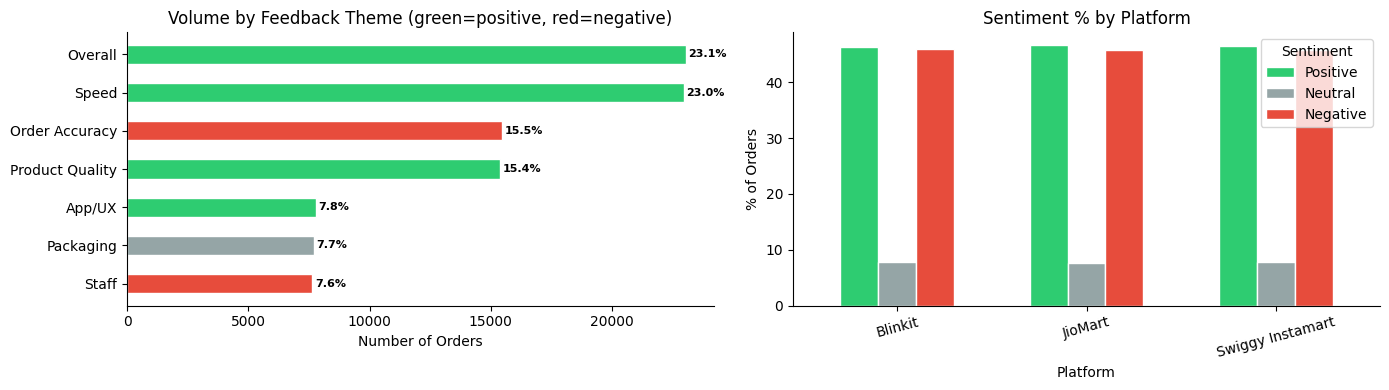

In [5]:
themes = df.groupby('Feedback_Theme').agg(
    Count       = ('Order ID',       'count'),
    Avg_Rating  = ('Service Rating', 'mean'),
    Refund_Rate = ('Refund_Flag',    'mean')
).sort_values('Count', ascending=True).round(2)

# colour by dominant sentiment
theme_sent = df.groupby('Feedback_Theme')['Sentiment'].agg(lambda x: x.mode()[0])
theme_colors = [SCOL[theme_sent[t]] for t in themes.index]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].barh(themes.index, themes['Count'], color=theme_colors, edgecolor='white', height=0.5)
axes[0].set_title('Volume by Feedback Theme (green=positive, red=negative)')
axes[0].set_xlabel('Number of Orders')
for i, v in enumerate(themes['Count'].values):
    axes[0].text(v+100, i, str(round(v/len(df)*100,1))+'%', va='center', fontsize=8, fontweight='bold')

sent_plat = df.groupby(['Platform','Sentiment']).size().unstack(fill_value=0)
sent_plat_pct = sent_plat.div(sent_plat.sum(axis=1), axis=0) * 100
sent_plat_pct[['Positive','Neutral','Negative']].plot(
    kind='bar', ax=axes[1],
    color=[SCOL['Positive'],SCOL['Neutral'],SCOL['Negative']],
    edgecolor='white', width=0.6
)
axes[1].set_title('Sentiment % by Platform')
axes[1].set_ylabel('% of Orders')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=15)
axes[1].legend(title='Sentiment')

plt.tight_layout()
plt.savefig('../visuals/12_sentiment_themes.png', dpi=150, bbox_inches='tight')
plt.show()


In [6]:
df.to_csv('../data/cleaned_with_sentiment.csv', index=False)
print("Saved cleaned_with_sentiment.csv")


Saved cleaned_with_sentiment.csv
